# Stroke Prediction

## Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns

## Import dataset

In [2]:
df = pd.read_csv('../dataset/healthcare-dataset-stroke-data.csv')

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
df.describe(include=[object])

,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


## Rename column for consistent formatting of name

In [7]:
df.rename(columns={'Residence_type': 'residence_type'}, inplace=True)

In [8]:
pd.set_option('display.max_columns', None)

In [9]:
pd.set_option('display.max_rows', None)

## Initial examination of dataset

### Gender column

In [10]:
gender_count = df['gender'].value_counts()
gender_count = gender_count.rename_axis('gender').reset_index(name='count')

In [11]:
gender_count

,gender,count
0,Female,2994
1,Male,2115
2,Other,1


### Age column

Text(0.5, 1.0, 'Age Box Plot')

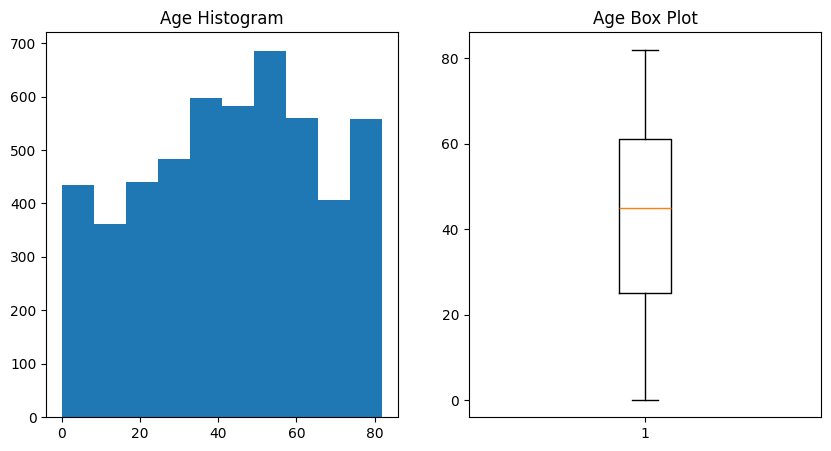

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(df['age'])
ax[0].set_title('Age Histogram')
ax[1].boxplot(df['age'])
ax[1].set_title('Age Box Plot')

### Hypertension column

In [13]:
hypertension_count = df['hypertension'].value_counts()
hypertension_count = hypertension_count.rename_axis('hypertension').reset_index(name='count')

In [14]:
hypertension_count

,hypertension,count
0,0,4612
1,1,498


### Heart disease column

In [15]:
heart_disease_count = df['heart_disease'].value_counts()
heart_disease_count = heart_disease_count.rename_axis('heart_disease').reset_index(name='count')

In [16]:
heart_disease_count

,heart_disease,count
0,0,4834
1,1,276


### Ever married column

In [17]:
ever_married_count = df['ever_married'].value_counts()
ever_married_count = ever_married_count.rename_axis('ever_married').reset_index(name='count')

In [18]:
ever_married_count

,ever_married,count
0,Yes,3353
1,No,1757


### Work type column

In [19]:
work_type_count = df['work_type'].value_counts()
work_type_count = work_type_count.rename_axis('work_type').reset_index(name='count')

In [20]:
work_type_count

,work_type,count
0,Private,2925
1,Self-employed,819
2,children,687
3,Govt_job,657
4,Never_worked,22


### Residence type column

In [21]:
residence_type_count = df['residence_type'].value_counts()
residence_type_count = residence_type_count.rename_axis('residence_type').reset_index(name='count')

In [22]:
residence_type_count

,residence_type,count
0,Urban,2596
1,Rural,2514


### Average glucose level column

Text(0.5, 1.0, 'Average Glucose Level Box Plot')

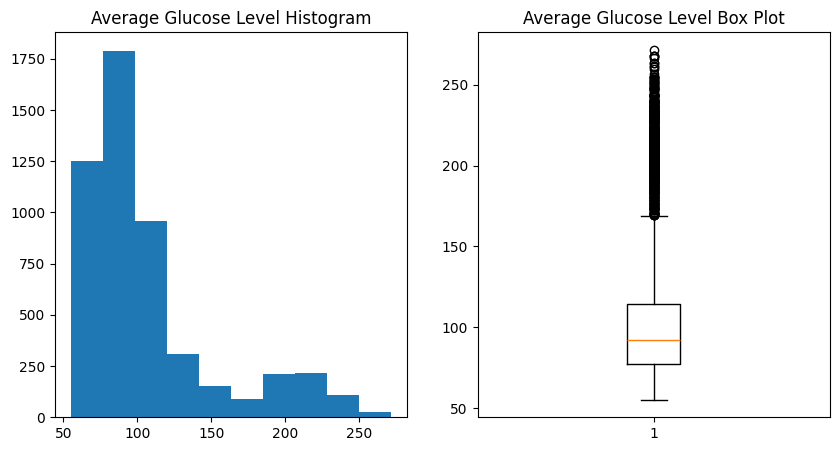

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(df['avg_glucose_level'])
ax[0].set_title('Average Glucose Level Histogram')
ax[1].boxplot(df['avg_glucose_level'])
ax[1].set_title('Average Glucose Level Box Plot')

### BMI column

In [24]:
bmi_clean = df['bmi'].dropna()

Text(0.5, 1.0, 'BMI Box Plot')

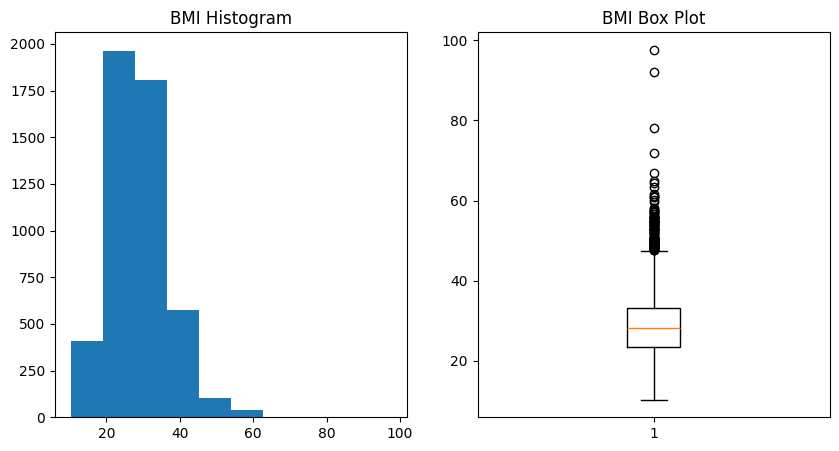

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(bmi_clean)
ax[0].set_title('BMI Histogram')
ax[1].boxplot(bmi_clean)
ax[1].set_title('BMI Box Plot')

### Smoking status column

In [26]:
smoking_status_count = df['smoking_status'].value_counts()
smoking_status_count = smoking_status_count.rename_axis('smoking_status').reset_index(name='count')

In [27]:
smoking_status_count

,smoking_status,count
0,never smoked,1892
1,Unknown,1544
2,formerly smoked,885
3,smokes,789


### Stroke event column

In [28]:
stroke_count = df['stroke'].value_counts()
stroke_count = stroke_count.rename_axis('stroke').reset_index(name='count')

In [29]:
stroke_count

,stroke,count
0,0,4861
1,1,249


### Gender vs Stroke

In [30]:
df.groupby('gender')['stroke'].value_counts()

gender  stroke
Female  0         2853
        1          141
Male    0         2007
        1          108
Other   0            1
Name: count, dtype: int64

### Age vs Stroke

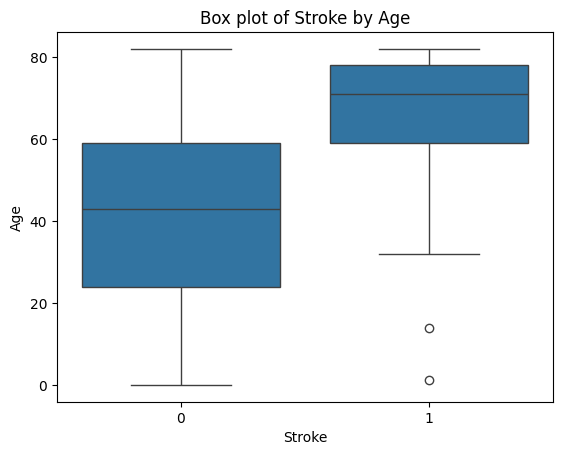

In [31]:
sns.boxplot(data=df, x='stroke', y='age')
plt.title('Box plot of Stroke by Age')
plt.xlabel('Stroke')
plt.ylabel('Age')
plt.show()

### Hypertension vs Stroke

In [32]:
df.groupby('hypertension')['stroke'].value_counts()

hypertension  stroke
0             0         4429
              1          183
1             0          432
              1           66
Name: count, dtype: int64

### Heart disease vs Stroke

In [33]:
df.groupby('heart_disease')['stroke'].value_counts()

heart_disease  stroke
0              0         4632
               1          202
1              0          229
               1           47
Name: count, dtype: int64

### Ever married vs Stroke

In [34]:
df.groupby('ever_married')['stroke'].value_counts()

ever_married  stroke
No            0         1728
              1           29
Yes           0         3133
              1          220
Name: count, dtype: int64

### Work type vs Stroke

In [35]:
df.groupby('work_type')['stroke'].value_counts()

work_type      stroke
Govt_job       0          624
               1           33
Never_worked   0           22
Private        0         2776
               1          149
Self-employed  0          754
               1           65
children       0          685
               1            2
Name: count, dtype: int64

### Residence type vs Stroke

In [36]:
df.groupby('residence_type')['stroke'].value_counts()

residence_type  stroke
Rural           0         2400
                1          114
Urban           0         2461
                1          135
Name: count, dtype: int64

### Average glucose level vs Stroke

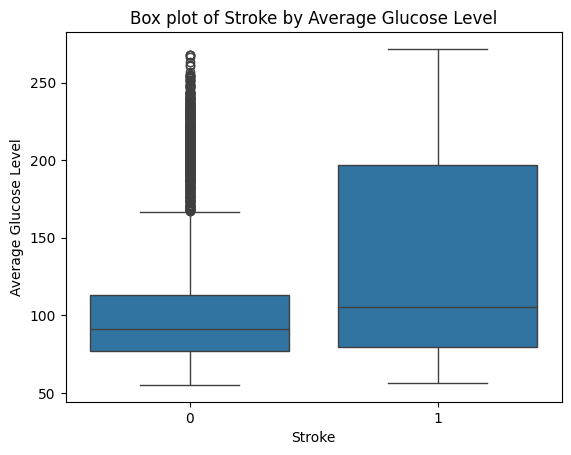

In [37]:
sns.boxplot(data=df, x='stroke', y='avg_glucose_level')
plt.title('Box plot of Stroke by Average Glucose Level')
plt.xlabel('Stroke')
plt.ylabel('Average Glucose Level')
plt.show()

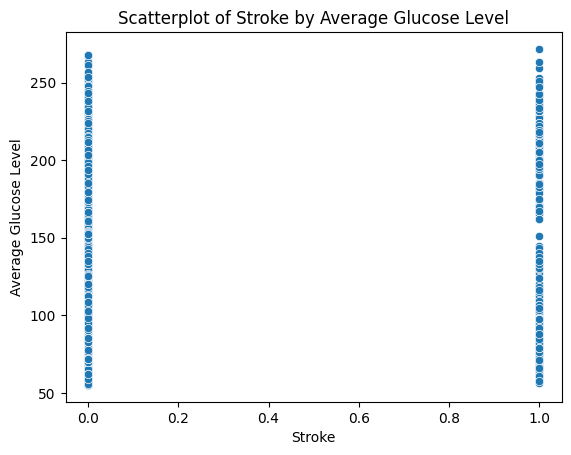

In [38]:
sns.scatterplot(data=df, x='stroke', y='avg_glucose_level')
plt.title('Scatterplot of Stroke by Average Glucose Level')
plt.xlabel('Stroke')
plt.ylabel('Average Glucose Level')
plt.show()

### BMI vs Stroke

Text(0, 0.5, 'BMI')

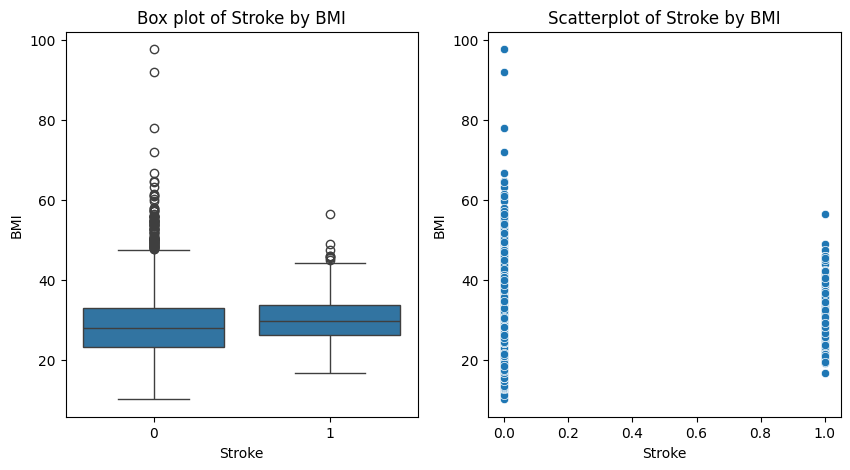

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(data=df, x='stroke', y='bmi', ax=ax[0])
ax[0].set_title('Box plot of Stroke by BMI')
ax[0].set_xlabel('Stroke')
ax[0].set_ylabel('BMI')

sns.scatterplot(data=df, x='stroke', y='bmi', ax=ax[1])
ax[1].set_title('Scatterplot of Stroke by BMI')
ax[1].set_xlabel('Stroke')
ax[1].set_ylabel('BMI')


### Smoking status vs Stroke

In [40]:
df.groupby('smoking_status')['stroke'].value_counts()

smoking_status   stroke
Unknown          0         1497
                 1           47
formerly smoked  0          815
                 1           70
never smoked     0         1802
                 1           90
smokes           0          747
                 1           42
Name: count, dtype: int64

### Impute missing values in BMI column
For 201 entries missing BMI values, these entries will be imputed with the median BMI value

In [41]:
median_bmi = df['bmi'].median()
df['bmi'].fillna(median_bmi, inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16204\2337012406.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(median_bmi, inplace=True)


In [42]:
print(df['bmi'].isna().sum())

0


### Further examination of BMI column

In [43]:
df_by_bmi = df.copy()
df_by_bmi = df_by_bmi.sort_values(by='bmi', ascending=False)

In [44]:
df_by_bmi.head(20)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
2128,56420,Male,17.0,1,0,No,Private,Rural,61.67,97.6,Unknown,0
4209,51856,Male,38.0,1,0,Yes,Private,Rural,56.90,92.0,never smoked,0
928,41097,Female,23.0,1,0,No,Private,Urban,70.03,78.0,smokes,0
544,545,Male,42.0,0,0,Yes,Private,Rural,210.48,71.9,never smoked,0
1559,37759,Female,53.0,0,0,Yes,Private,Rural,72.63,66.8,Unknown,0
358,66333,Male,52.0,0,0,Yes,Self-employed,Urban,78.40,64.8,never smoked,0
4188,70670,Female,27.0,0,0,Yes,Private,Rural,57.96,64.4,never smoked,0
2764,20292,Female,24.0,0,0,Yes,Private,Urban,85.55,63.3,never smoked,0
3825,72784,Female,52.0,0,0,Yes,Private,Rural,118.46,61.6,smokes,0
2840,65895,Female,52.0,0,0,Yes,Private,Urban,98.27,61.2,Unknown,0


In [45]:
df['bmi'].quantile(0.25)

23.8

In [46]:
df['bmi'].quantile(0.5)

28.1

In [47]:
df['bmi'].quantile(0.75)

32.8

In [48]:
df['bmi'].quantile(0.75) + 1.5 * (df['bmi'].quantile(0.75) - df['bmi'].quantile(0.25))

46.29999999999999

In [49]:
df_by_bmi_extreme = df_by_bmi[df_by_bmi['bmi'] >= 46.3]

In [50]:
df_by_bmi_extreme.shape

(125, 12)

In [51]:
df_by_bmi_extreme['stroke'].sum()

3

### Further examination of Average glucose level column

In [52]:
df_by_avg_glucose_level = df.copy()
df_by_avg_glucose_level = df_by_avg_glucose_level.sort_values(by='avg_glucose_level', ascending=False)

In [53]:
df_by_avg_glucose_level.head(20)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
193,69112,Male,68.0,1,1,Yes,Private,Rural,271.74,31.1,smokes,1
1207,22440,Female,49.0,0,0,Yes,Private,Urban,267.76,29.3,formerly smoked,0
3088,26267,Female,76.0,0,0,Yes,Self-employed,Urban,267.61,27.9,smokes,0
4983,10995,Male,76.0,1,0,Yes,Private,Rural,267.60,30.5,never smoked,0
2462,27626,Female,60.0,0,0,No,Govt_job,Rural,266.59,25.5,never smoked,0
3393,13155,Female,67.0,1,0,Yes,Govt_job,Rural,263.56,26.3,never smoked,0
135,71279,Female,71.0,0,0,Yes,Govt_job,Urban,263.32,38.7,never smoked,1
4457,50070,Female,62.0,1,0,Yes,Self-employed,Rural,261.67,43.0,formerly smoked,0
3215,21534,Male,67.0,0,0,Yes,Private,Urban,260.85,28.1,Unknown,0
122,13491,Male,80.0,0,0,Yes,Private,Rural,259.63,31.7,smokes,1


In [54]:
df['avg_glucose_level'].quantile(0.25)

77.245

In [55]:
df['avg_glucose_level'].quantile(0.5)

91.88499999999999

In [56]:
df['avg_glucose_level'].quantile(0.75)

114.09

In [57]:
df['avg_glucose_level'].quantile(0.75) + 1.5 * (df['avg_glucose_level'].quantile(0.75) - df['avg_glucose_level'].quantile(0.25))

169.35750000000002

In [58]:
df_by_avg_glucose_level_extreme = df_by_avg_glucose_level[df_by_avg_glucose_level['avg_glucose_level'] >= 169.3575]

In [59]:
df_by_avg_glucose_level_extreme.shape

(627, 12)

In [60]:
df_by_avg_glucose_level_extreme['stroke'].sum()

84

## Feature Engineering

### Converting categorical columns to numerical columns

In [61]:
df['male'] = (df['gender'] == 'Male').astype(int)

In [62]:
df['ever_married'] = (df['ever_married'] == 'Yes').astype(int)

In [63]:
df['urban'] = (df['residence_type'] == 'Urban').astype(int)

In [64]:
df['smoke'] = ((df['smoking_status'] == 'formerly smoked') | (df['smoking_status'] == 'smokes')).astype(int)

In [65]:
df['have_work'] = ((df['work_type'] == 'Govt_job') | (df['work_type'] == 'Private') | (df['work_type'] == 'Self-employed')).astype(int)

In [66]:
df['hypertension_or_heart_disease'] = df['hypertension'] | df['heart_disease']

In [67]:
df = pd.get_dummies(df, columns=['work_type', 'smoking_status'], drop_first = False)

### Extra columns with interaction features

In [68]:
df['age_ever_married'] = df['age'] * df['ever_married']

In [69]:
df['age_hypertension'] = df['age'] * df['hypertension']

In [70]:
df['age_heart_disease'] = df['age'] * df['heart_disease']

### Creating columns representing outstanding values for BMI and Average Glucose Level

In [71]:
df['obese'] = df['bmi'] >= 30

In [72]:
df['high_avg_glucose_level'] = df['avg_glucose_level'] >= 150

In [73]:
df['obese_high_avg_glucose_level'] = df['obese'] | df['high_avg_glucose_level']

### Creating column representing high age

In [74]:
df['old'] = df['age'] >= 65

### Converting boolean columns to numerical

In [75]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

### Accounting for multiple risks

In [76]:
df['risk_count'] = df['obese'] + df['high_avg_glucose_level'] + df['old'] + df['hypertension'] + df['heart_disease']

### Reformatting column names

In [77]:
df.rename(columns={'work_type_Govt_job': 'work_type_govt_job', 'work_type_Never_worked': 'work_type_never_worked', 'work_type_Private': 'work_type_private', 'work_type_Self-employed': 'work_type_self_employed'}, inplace=True)

In [78]:
df.rename(columns={'smoking_status_Unknown': 'smoking_status_unknown', 'smoking_status_formerly smoked': 'smoking_status_formerly_smoked', 'smoking_status_never smoked': 'smoking_status_never_smoked'}, inplace=True)

In [79]:
df.drop(columns=['gender', 'residence_type'], inplace=True)

### Log Transforming BMI and Average Glucose Level columns

In [80]:
df['log_bmi'] = np.log(df['bmi'])

In [81]:
df['log_avg_glucose_level'] = np.log(df['avg_glucose_level'])

In [82]:
df.head()

,id,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,male,urban,smoke,have_work,hypertension_or_heart_disease,work_type_govt_job,work_type_never_worked,work_type_private,work_type_self_employed,work_type_children,smoking_status_unknown,smoking_status_formerly_smoked,smoking_status_never_smoked,smoking_status_smokes,age_ever_married,age_hypertension,age_heart_disease,obese,high_avg_glucose_level,obese_high_avg_glucose_level,old,risk_count,log_bmi,log_avg_glucose_level
0,9046,67.0,0,1,1,228.69,36.6,1,1,1,1,1,1,0,0,1,0,0,0,1,0,0,67.0,0.0,67.0,1,1,1,1,4,3.600048,5.432367
1,51676,61.0,0,0,1,202.21,28.1,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,61.0,0.0,0.0,0,1,1,0,1,3.335770,5.309307
2,31112,80.0,0,1,1,105.92,32.5,1,1,0,0,1,1,0,0,1,0,0,0,0,1,0,80.0,0.0,80.0,1,0,1,1,3,3.481240,4.662684
3,60182,49.0,0,0,1,171.23,34.4,1,0,1,1,1,0,0,0,1,0,0,0,0,0,1,49.0,0.0,0.0,1,1,1,0,2,3.538057,5.143008
4,1665,79.0,1,0,1,174.12,24.0,1,0,0,0,1,1,0,0,0,1,0,0,0,1,0,79.0,79.0,0.0,0,1,1,1,3,3.178054,5.159745


## Correlation Examination

In [83]:
columns_name = [col for col in df.columns if col != 'id']

In [84]:
columns_name

['age',
 'hypertension',
 'heart_disease',
 'ever_married',
 'avg_glucose_level',
 'bmi',
 'stroke',
 'male',
 'urban',
 'smoke',
 'have_work',
 'hypertension_or_heart_disease',
 'work_type_govt_job',
 'work_type_never_worked',
 'work_type_private',
 'work_type_self_employed',
 'work_type_children',
 'smoking_status_unknown',
 'smoking_status_formerly_smoked',
 'smoking_status_never_smoked',
 'smoking_status_smokes',
 'age_ever_married',
 'age_hypertension',
 'age_heart_disease',
 'obese',
 'high_avg_glucose_level',
 'obese_high_avg_glucose_level',
 'old',
 'risk_count',
 'log_bmi',
 'log_avg_glucose_level']

In [85]:
full_corr_matrix = df[columns_name].corr()

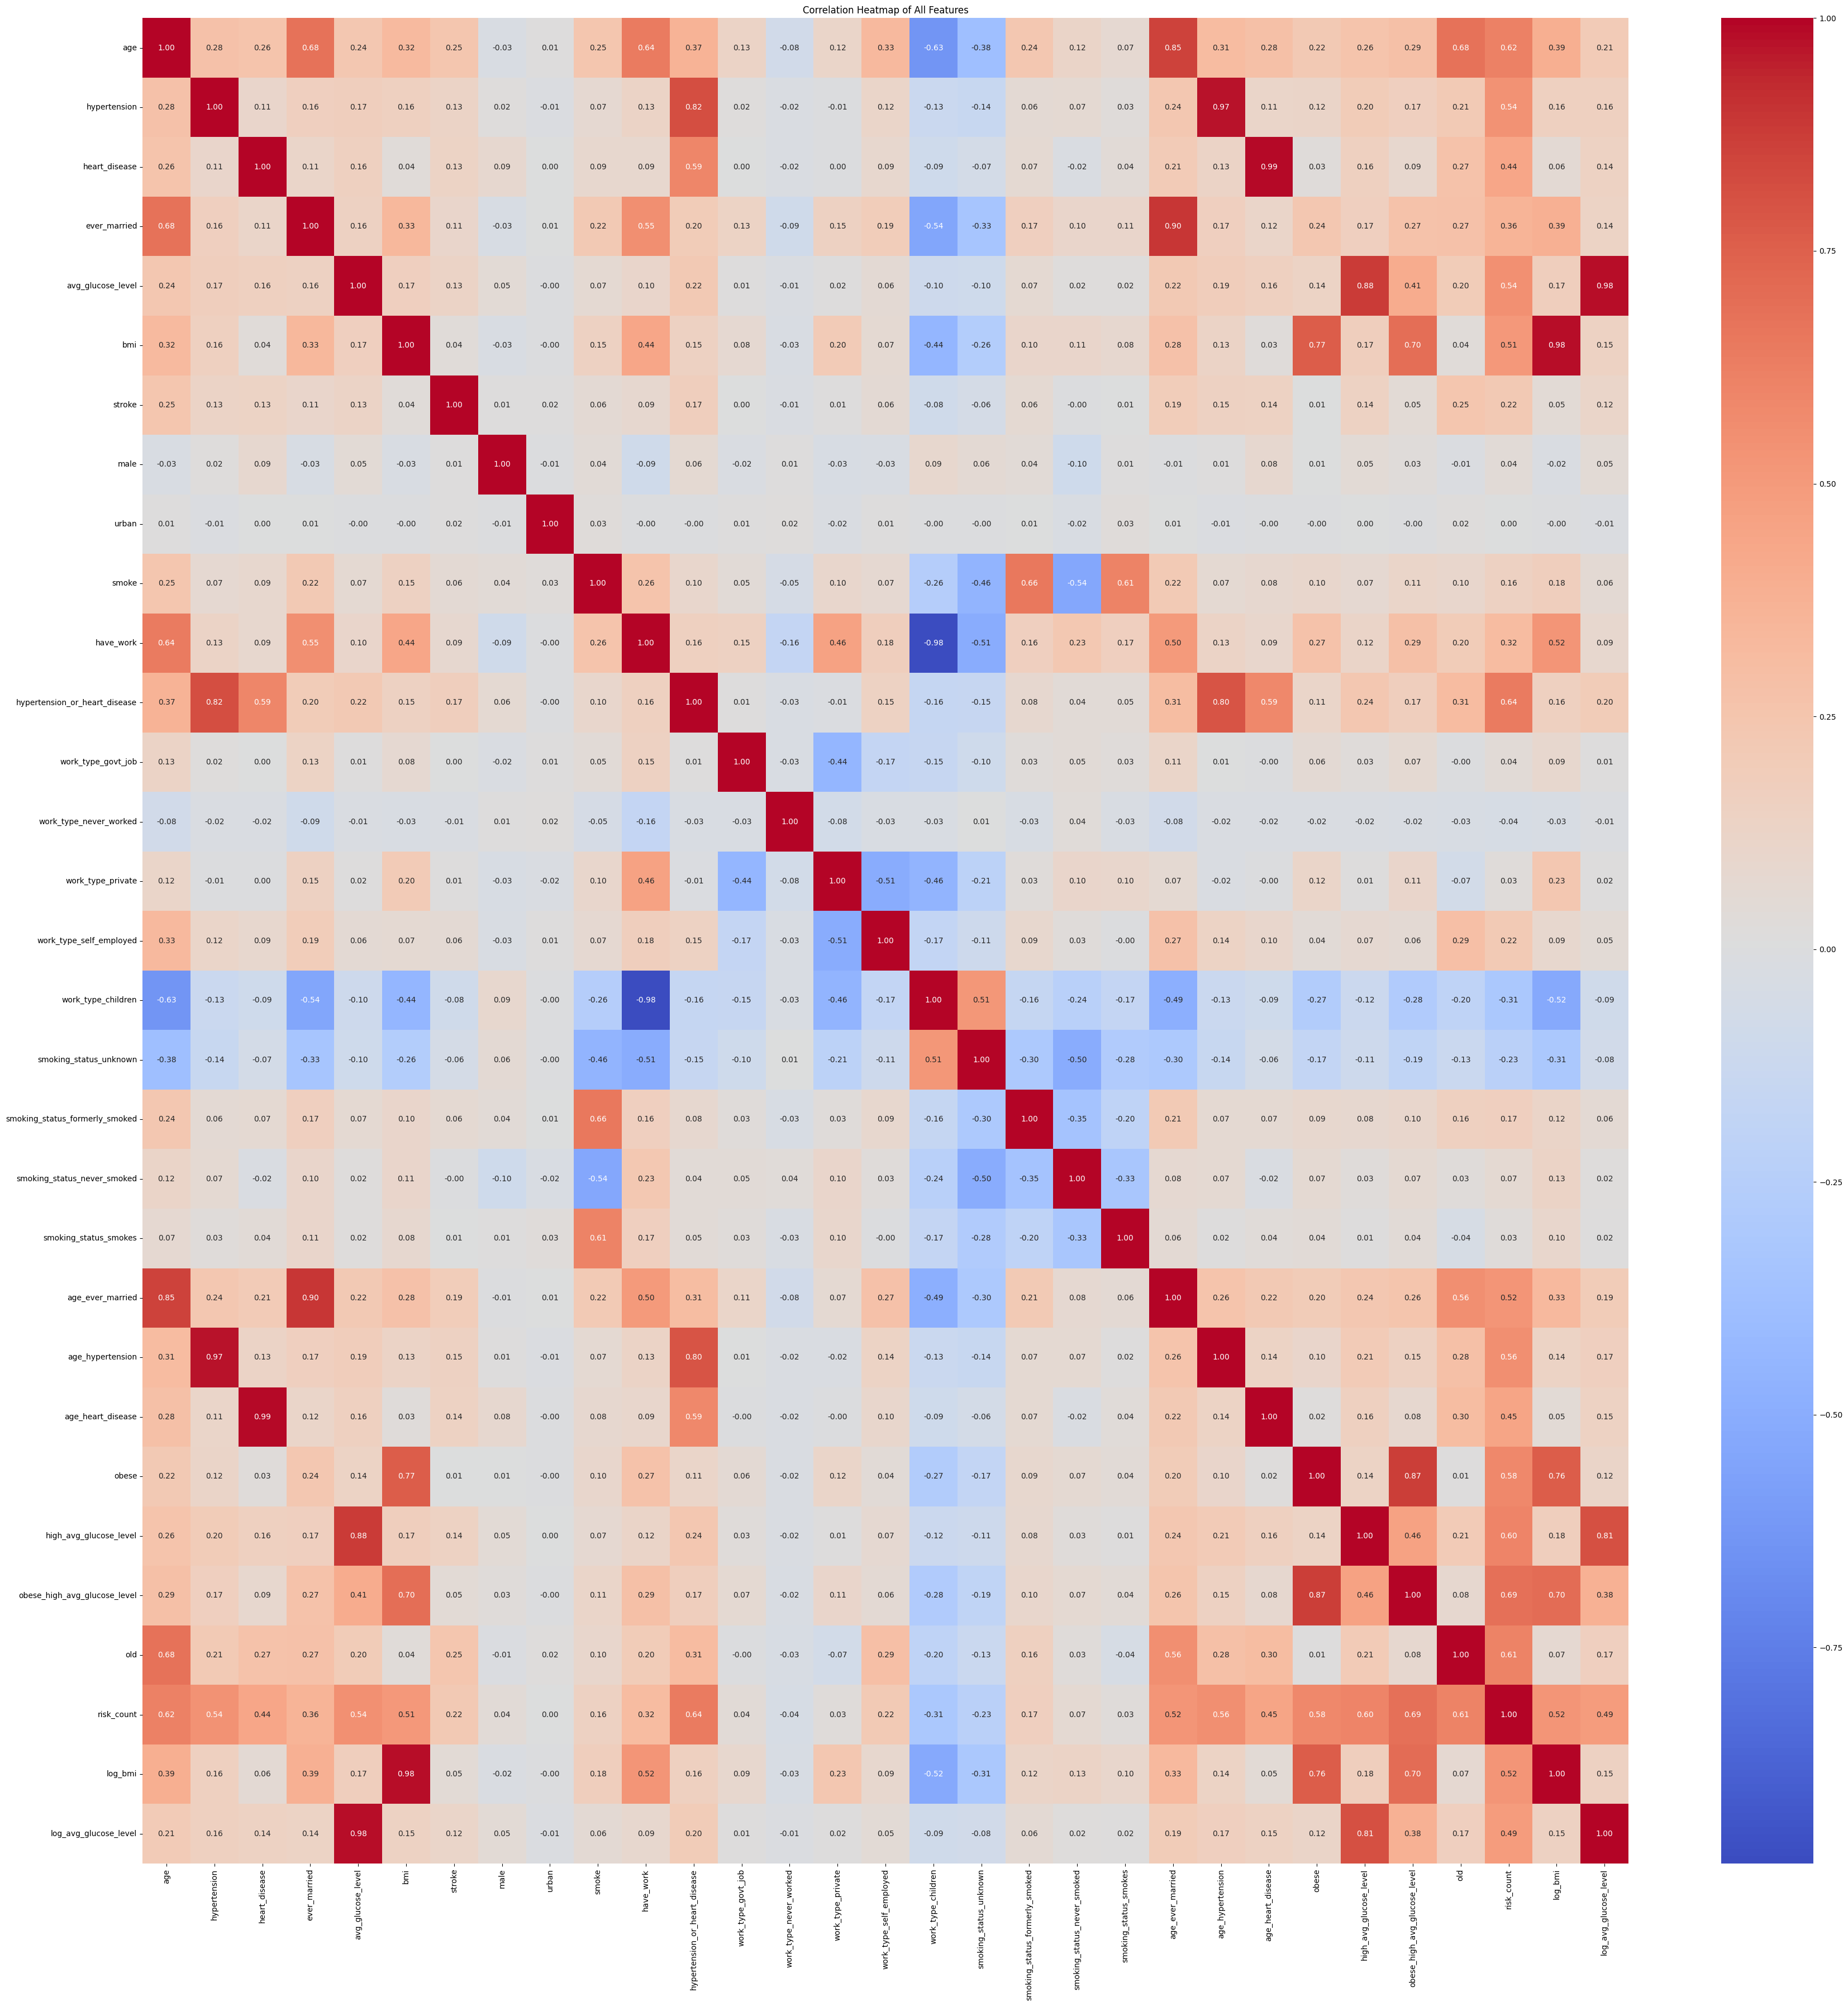

In [86]:
plt.figure(figsize=(36, 36))
sns.heatmap(full_corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title("Correlation Heatmap of All Features")
plt.tight_layout()
plt.show()